20260614
## Linear Regression
- to predict continuous data.
- straight line y = mx + C  
y = prediction data
m = slope/coefficient (b1) -> covariance(x,y)/variance(x)   
x = actual data       
c = y-intercept (b0) -> constant        

1. simple linear regression:
   - one feature one target
   - y = b0 + b1x1
2. multiple linear regression:
 - multiple feature one target
  - y = b0+b1x1+b2x2 + ....... + bnxn

### Important logics
If there are ten features then it is not 10 separate lines, its one equation with 10 slopes. With one feature, you can literally draw a line on a 2D graph (x vs y). With 10 features, you can't draw it on paper anymore, but the idea is the same: instead of a line in 2D, you get a flat surface (a hyperplane) in 11 dimensional space (10 feature dimensions + 1 target dimension). We can't visualize that, but the math is a natural extension.
y=β0+β1x1+β2x2+β3x3+⋯+β10x10



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

In [4]:
cor = df.corr()

### Split data

In [ ]:
'''
X -> Feature
Y -> Target
test_size -> split test size
random_state = 42(index)
random_state -> data shuffle, 42th index extract data
'''

<Axes: >

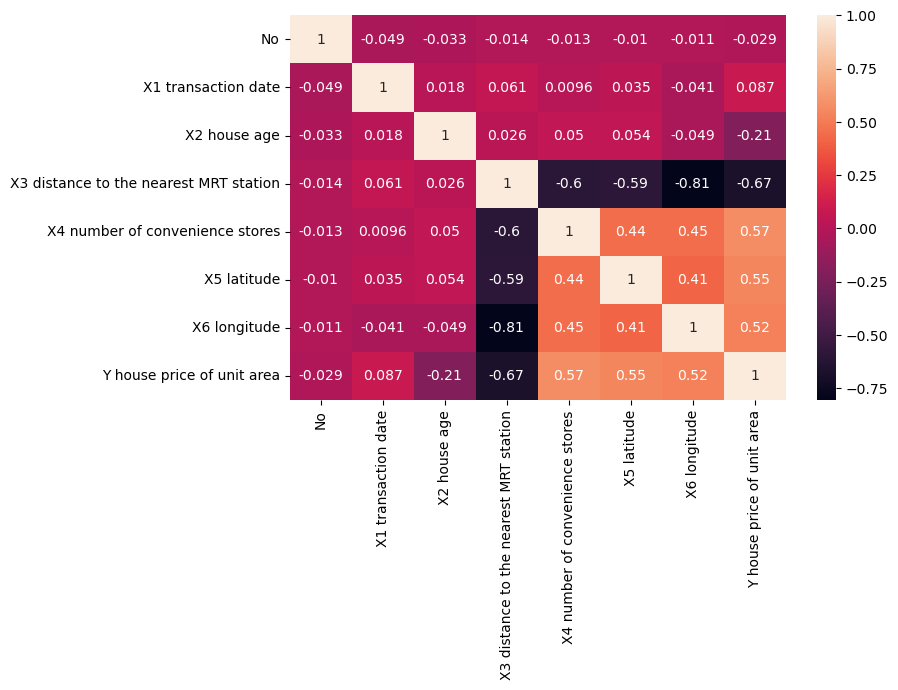

In [7]:
plt.figure(figsize=(8,5))
sns.heatmap(cor, annot=True)

In [8]:
# feature always must be multi dimension
# target always must be one dimension

In [58]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

<Axes: ylabel='Y house price of unit area'>

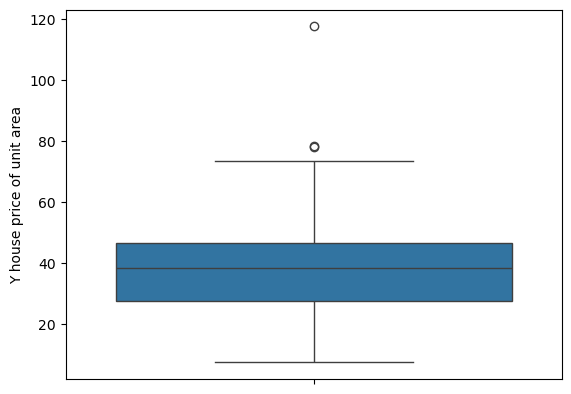

In [87]:
sns.boxplot(df['Y house price of unit area'])

In [88]:
df_clean = df[df['Y house price of unit area'] < 75]

In [89]:
feature= [ 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [90]:
X =df[feature]
Y=df[target]

In [91]:
#Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,test_size = 0.2,random_state=42
)

In [92]:
# to bring the data in the same range
scaler = StandardScaler()

In [93]:
#fit_transform -> feature training -> fit(Learning) transform(Implement)
#transform (implementation) -> feature testing
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#### Linear Regression Model

In [94]:
model = LinearRegression()

In [95]:
# Training model
model.fit(X_train_scale,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-3.06,-5.54, 3.26, 2.94,-0.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.39
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[29.57,18.38,14.39,13.51, 7.32]"


In [96]:
beta_0 = model.coef_
beta_1 = model.intercept_

print(f'Slope / Coefficient: {beta_0}')
print(f'Intercept: {beta_1}')

Slope / Coefficient: [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]
Intercept: 38.39154078549814


In [97]:
# testing model
# y = b0 + b1.x1 + b2.x2 + ..... + bn.xn
Y_pred = model.predict(X_test_scale)

In [98]:
Y_pred

array([47.74180481, 41.95484652, 44.5399885 , 41.33697932, 30.28548   ,
       42.84474934, 45.98717123, 45.90599326, 24.78369465, 52.02068924,
       32.23880597, 34.77542016, 39.51392044, 24.90203898, 35.73984968,
       32.99552705, 41.96863217, 46.98662328, 31.50100311, 44.49258341,
        2.21362693, 33.64381059, 47.764103  , 43.56374399, 14.07301949,
       41.29883092, 14.73315281, 44.5399885 , 36.13972668, 37.76019401,
       11.66211419, 39.22848089, 37.83881729, 28.61334713, 45.93500741,
       31.52925298, 52.2101045 , 15.18188713, 46.84531477, 40.47464938,
       36.01694465, 40.58052131, 48.38869976, 39.8943259 , 42.00896517,
       48.22742934, 45.07252677, 23.5290158 , 49.9849698 , 48.13933326,
       47.74180481, 48.54209921, 40.94754085, 42.54642454, 36.38766353,
       15.15482781, 35.13348041, 36.39866246, 30.20430203, 45.90599326,
       33.69672647, 32.65567761, 15.15482781, 11.8739673 ,  8.74877596,
       33.67086991, 29.81801432, 45.24751413, 34.2425491 , 30.54

**to calculate whether the model is working well or not**

#### Metrics

In [99]:
mae = mean_absolute_error(Y_test,Y_pred) # sum of all data distance / number of records
mse = mean_squared_error(Y_test,Y_pred) # squared sum of all distance / number of records
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred)) # root mean squared error
r2 = r2_score(Y_test,Y_pred) # accuracy

In [100]:
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R2 score: {r2}')

Mean Absolute Error: 5.350138374356212
Mean Squared Error: 54.580945200862146
Root Mean Squared Error: 7.3878917967754605
R2 score: 0.6746481382828176


#### visualization
**20260615**

<Axes: xlabel='Y house price of unit area'>

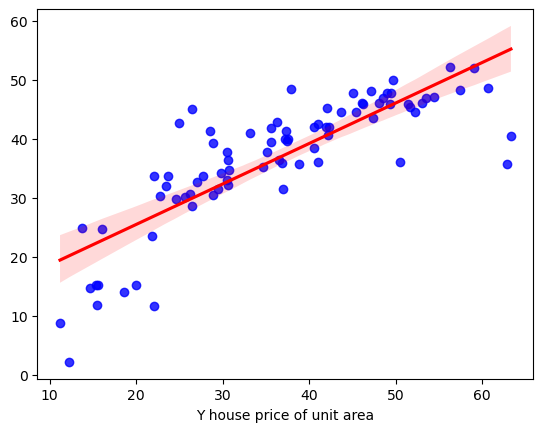

In [101]:
sns.regplot(x=Y_test,y=Y_pred,color='blue', line_kws={'color':'red'})

In [102]:
min_val = min(Y_test.min(),Y_pred.min())
max_val = max(Y_test.max(),Y_pred.max())

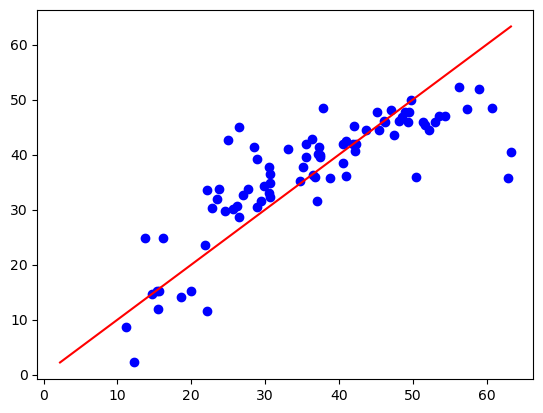

In [103]:
plt.scatter(Y_test,Y_pred, color='blue')
plt.plot([min_val,max_val], [min_val,max_val], color='red')

In [104]:
from sklearn.ensemble import RandomForestRegressor

In [105]:
rf = RandomForestRegressor(n_estimators = 100)

In [106]:
rf.fit(X_train_scale, Y_train)
rf_pred = rf.predict(X_test_scale)

In [107]:
rf_rmse = np.sqrt(mean_squared_error(Y_test,rf_pred))
rf_r2 = r2_score(Y_test,rf_pred)

In [108]:
print(rf_rmse)
print(rf_r2)

5.8527121942516676
0.7958137089043584


<Axes: xlabel='Y house price of unit area'>

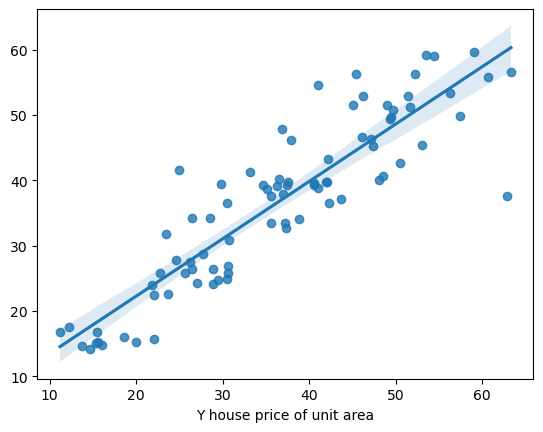

In [109]:
sns.regplot(x=Y_test,y=rf_pred)

In [110]:
data = {
    'X2 house age': [3,2,5],
       'X3 distance to the nearest MRT station': [287.6025, 84.87882,323.655] ,
       'X4 number of convenience stores':[10,3,5],
        'X5 latitude': [24.99156,24.97528,121.54024],
        'X6 longitude':[121.48458,121.51151,121.54024]
}

In [111]:
test_df = pd.DataFrame(data)

In [112]:
test_scale = scaler.transform(test_df)

In [117]:
test_pred = model.predict(test_scale)
test_rf_pred = rf.predict(test_scale)

In [118]:
test_df['Predicted Price'] = test_pred
test_df['RF_Predicted_Price']  = test_rf_pred

In [119]:
test_df

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Predicted Price,RF_Predicted_Price
0,3,287.60250,10,24.99156,121.48458,58.669161,64.943950
1,2,84.87882,3,24.97528,121.51151,47.639490,58.722667
2,5,323.65500,5,121.54024,121.54024,22845.558943,50.807000
